# Grouping
### In this lesson we will go over the split-apply-combine strategy and the groupby() function.

This lesson is based on the [R lesson on summary statistics using group-by](https://learning.nceas.ucsb.edu/2023-06-delta/session_11.html#summary-statistics-using-group_by-and-summarize) and summarize [1] co-developed at the NCEAS Learning Hub.

## Learning objectives
By the end of this lesson, students will be able to:

- Understand and apply the Split-Apply-Combine strategy to analyze grouped data.
- Use groupby() to split a pandas.DataFrame by one or more columns.
- Calculate summary statistics for groups in a pandas.DataFrame.
- Use method chaining for readable data analysis.
- Explain how groupby() handles NA values and choose between count() and size() to count observations in each group.

In [2]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Summary statistics
It is easy to get summary statistics for each column in a pandas.DataFrame by using methods such as:

- sum(): sum values in each column,
- count(): count non-NA values in each column,
- size(): count the number of values in a column (including NA values),
- min() and max(): get the minimum and maximum value in each column,
- mean() and median(): get the mean and median value in each column,
- std() and var(): get the standard deviation and variance in each column.

In [3]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [4]:
# Get minimum value in each column with numerical values
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping
0. We start with our data and notice there are multiple species in the species column.

1. We split our original table to group all observations from the same species together.

2. We calculate the average flipper length for each of the groups we formed.

3. Then we combine the values for average flipper length per species into a single table.

This is known as the **Split-Apply-Combine** strategy. This strategy follows the three steps we explained above:

- **Split**: Split the data into logical groups (e.g. species, sex, island, etc.)

- **Apply**: Calculate some summary statistic on each group (e.g. average flipper length by species, number of individuals per island, body mass by sex, etc.)

- **Combine**: Combine the statistic calculated on each group back together.

`df.groupby(columns_to_group_by).summary_method()`

In [5]:
penguins['flipper_length_mm'].mean()

200.91520467836258

In [6]:
penguins.groupby('species')['flipper_length_mm']

In [7]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [9]:
# Notice that the name of the series is the same as the column 
# on which we calculated the summary statistic. 
# We can easily update this using the rename() method:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [10]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping and NA values

In [11]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

In [12]:
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

### Check IN
We are interested in knowing the number of penguins surveyed on each island in different years.

1. Run

penguins.groupby(['island','year']).count()

and

penguins.groupby(['island','year']).size()

2. Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

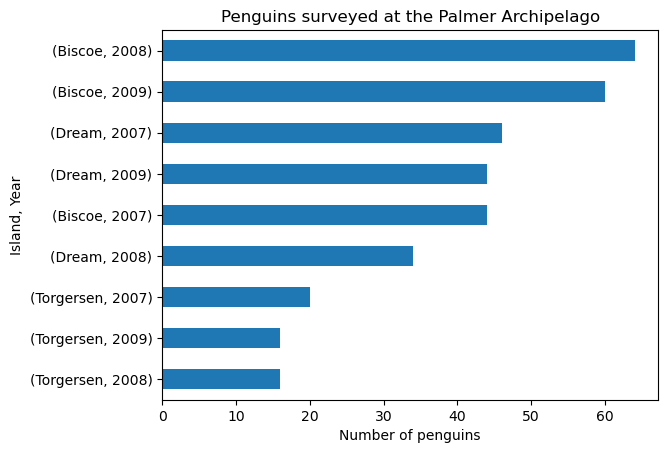

In [13]:
## Let’s say we want to plot the surveyed population 
# per year and island. 
# We could then use method chaining to do this:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

### Check In
1. Use the max() method to calculate the maximum value of a penguin’s body mass by year and species.

2. Use (1) to display the highest body masses per year and species as a bar plot in descending order.